In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(
    "IAPT_activity _march 2026.csv"
)

In [3]:
df.head()

,REPORTING_PERIOD_START,REPORTING_PERIOD_END,GROUP_TYPE,ORG_CODE1,ORG_NAME1,ORG_CODE2,ORG_NAME2,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE_SUPPRESSED
0,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M001,Count_ReferralsReceived,163100
1,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M002,Count_SelfReferrals,111830
2,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M003,Count_GPReferrals,13461
3,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M004,Count_HealthVisitorReferrals,433
4,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M005,Count_OtherPrimaryCareReferrals,5840


In [4]:
df.columns

Index(['REPORTING_PERIOD_START', 'REPORTING_PERIOD_END', 'GROUP_TYPE',
       'ORG_CODE1', 'ORG_NAME1', 'ORG_CODE2', 'ORG_NAME2', 'MEASURE_ID',
       'MEASURE_NAME', 'MEASURE_VALUE_SUPPRESSED'],
      dtype='object')

DNA AND DROP OFF MEASURES

In [5]:
dna_df = df[
    df['MEASURE_NAME'].isin([

        'Count_ApptsDNA',
        'Count_ApptsAttended',
        'Count_FirstToSecondTreatment',
        'Count_SecondTreatment'

    ])
]

dna_df.head()

,REPORTING_PERIOD_START,REPORTING_PERIOD_END,GROUP_TYPE,ORG_CODE1,ORG_NAME1,ORG_CODE2,ORG_NAME2,MEASURE_ID,MEASURE_NAME,MEASURE_VALUE_SUPPRESSED
77,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M084,Count_ApptsDNA,59816
79,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M086,Count_ApptsAttended,545055
138,2026-03-01,2026-03-31,England,all,all SubICBs,all,all Providers,M184,Count_SecondTreatment,54683
294,2026-03-01,2026-03-31,CommissioningRegion,InvalidRegionCode,Unknown,all,all Providers,M084,Count_ApptsDNA,615
296,2026-03-01,2026-03-31,CommissioningRegion,InvalidRegionCode,Unknown,all,all Providers,M086,Count_ApptsAttended,8350


In [6]:
dna_df[
    'MEASURE_VALUE_SUPPRESSED'
] = pd.to_numeric(

    dna_df['MEASURE_VALUE_SUPPRESSED'],
    errors='coerce'

)

/tmp/ipykernel_3237/3798548084.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dna_df[


missing values


In [7]:
dna_df = dna_df.dropna(
    subset=['MEASURE_VALUE_SUPPRESSED']
)

create summary table

In [8]:
dna_summary = dna_df.groupby(
    'MEASURE_NAME'
)['MEASURE_VALUE_SUPPRESSED'].sum()

dna_summary

,MEASURE_VALUE_SUPPRESSED
MEASURE_NAME,
Count_ApptsAttended,2724550.0
Count_ApptsDNA,298866.0
Count_SecondTreatment,273238.0


In [9]:
summary_table = pd.DataFrame({

    "Measure":
    dna_summary.index,

    "Count":
    dna_summary.values

})

summary_table

,Measure,Count
0,Count_ApptsAttended,2724550.0
1,Count_ApptsDNA,298866.0
2,Count_SecondTreatment,273238.0


funnel chart

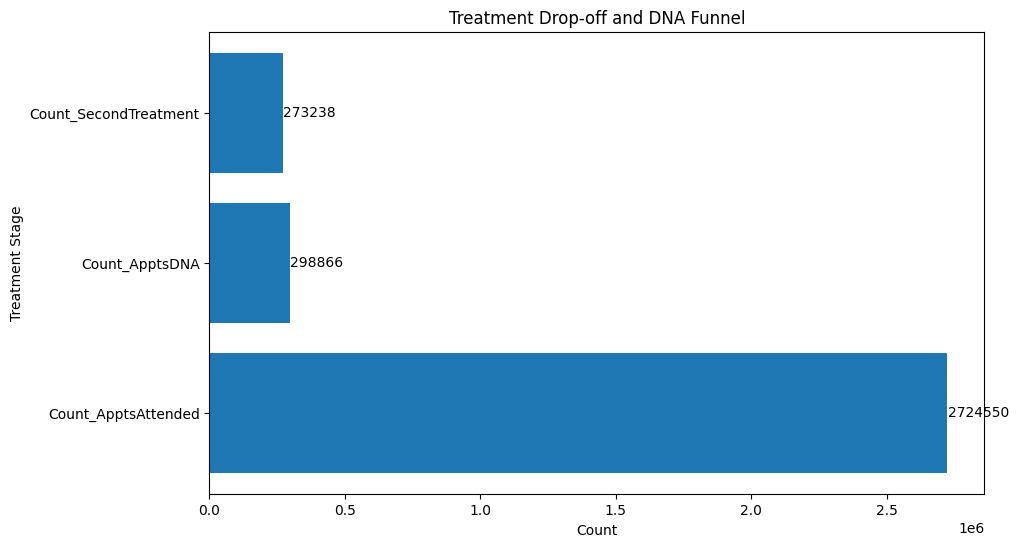

In [10]:
plt.figure(figsize=(10,6))

bars = plt.barh(

    summary_table['Measure'],
    summary_table['Count']

)

plt.xlabel("Count")

plt.ylabel("Treatment Stage")

plt.title(
    "Treatment Drop-off and DNA Funnel"
)

for bar in bars:

    width = bar.get_width()

    plt.text(

        width + 100,

        bar.get_y()
        +
        bar.get_height()/2,

        int(width),

        va='center'

    )

plt.show()

In [11]:
summary_table.to_csv(

    "dna_dropoff_summary.csv",

    index=False
)